In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.stats.api as sms
from statsmodels.compat import lzip
from statsmodels.stats.diagnostic import het_white
from statsmodels.stats.stattools import durbin_watson
import pylab
import scipy.stats as stats 
from statsmodels.stats.diagnostic import normal_ad

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn import datasets

En anteriores sesiones nos encargamos de estudiar y ajustar en algunos conjuntos de datos el modelo de Regresión Lineal Simple y Multiple.
Estos modelos se construyeron bajo una serie de supuestos sobre  $X$, $Y$ para estar correctamente justificados.
Estos supuestos son los siguientes:

1.- LINEALIDAD: La relación funcional entre la variable de respuesta $Y$ y cada regresor $X_j$ es lineal $j$=1,2,...,k.

2.- MEDIA DE LOS RESIDUOS : La esperanza de los errores es cero  $\mathbb{E}(\varepsilon)=0 $

3.- HOMOCEDASTICIDAD: La varianza de los errores es constante $\mathbb{Var}(\varepsilon)=\sigma^2 $

4.- ERRORES NO AUTOCORRELACIONADOS: Los errores no están correlacionados   $\mathbb{Cov}(\varepsilon_i,\varepsilon_j)= 0 $ con $ i $ != $ j $

5.- NORMALIDAD DE LOS ERRORES: Los errores tienen una distribución normal con media cero y varianza $\sigma^2 $ Es decir: $e_i \sim N(0, \sigma^{2}))$.


Además debemos asegurar que el modelo no tenga MULTICOLINEALIDAD, es decir que todas nuestras variables predictoras son linealmente independientes (ortogonales)


Si un modelo de regresión no cumple los anteriores supuestos entonces puede tener diversas implicaciones y efectos en la validez de las inferencias y predicciones realizadas con el modelo. Aquí hay algunas posibles consecuencias:

- INFERENCIAS NO VALIDAS:
Los intervalos de confianza y las pruebas de hipótesis que se basan en supuestos específicos pueden no ser válidos. Esto significa que las conclusiones que se extraigan del análisis estadístico podrían ser erróneas o poco confiables.


- COEFICIENTES DE REGRESION SESGADOS: 
Los coeficientes estimados pueden estar sesgados o tener varianzas sesgadas si los supuestos no se cumplen. Esto afectaría la interpretación de la importancia de las variables predictoras y la dirección de sus efectos.

- PREDICCIONES INEXACTAS: 
Si los supuestos no se cumplen, las predicciones del modelo pueden ser inexactas. Los errores de predicción pueden ser sistemáticamente sesgados o tener una variabilidad inapropiada.

- PROBLEMAS DE MULTICOLINEALIDAD: 
La multicolinealidad entre las variables predictoras puede hacer que los coeficientes sean difíciles de interpretar y aumentar la varianza de las estimaciones, lo que afecta la estabilidad del modelo.

- SENSIBILIDAD DE VALORES ATIPICOS: 
Los valores atípicos pueden tener un impacto más pronunciado en el modelo si no se cumplen los supuestos, distorsionando las estimaciones de los parámetros y afectando la calidad del ajuste.

- MODELO NO ROBUSTO: 
La falta de robustez del modelo puede hacer que sea sensible a pequeños cambios en los datos, lo que podría resultar en predicciones y conclusiones inestables.








Es importante tener en cuenta que, en la práctica, algunos de estos supuestos pueden no cumplirse completamente. En tales casos, es crucial realizar un análisis cuidadoso y considerar técnicas alternativas o transformaciones de datos si es necesario. Si partimos los datos en conjuntos de prueba y entrenamiento generalmente se validan los supuestos con el conjuntos de entrenamiento, ya que ahí es donde se ajustaron los parametros del modelo


En este notebook nos encargaremos de hacer el diagnostico completo del modelo. Se presentarán las técnicas y metodos para validar los anteriores supuestos. Se utilizarán dos conjuntos de datos para mostras un escenario en el que los supuestos se cumplen y otro en el que no

### CONJUNTO DE DATOS 1 (CUMPLE SUPUESTOS)

In [50]:
df = pd.read_csv("publicidad.csv")

In [51]:
df.shape

(200, 5)

In [53]:
df.describe()

,id,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [54]:
df.head(2)

,id,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4


In [5]:
df.drop(columns="id",inplace=True)

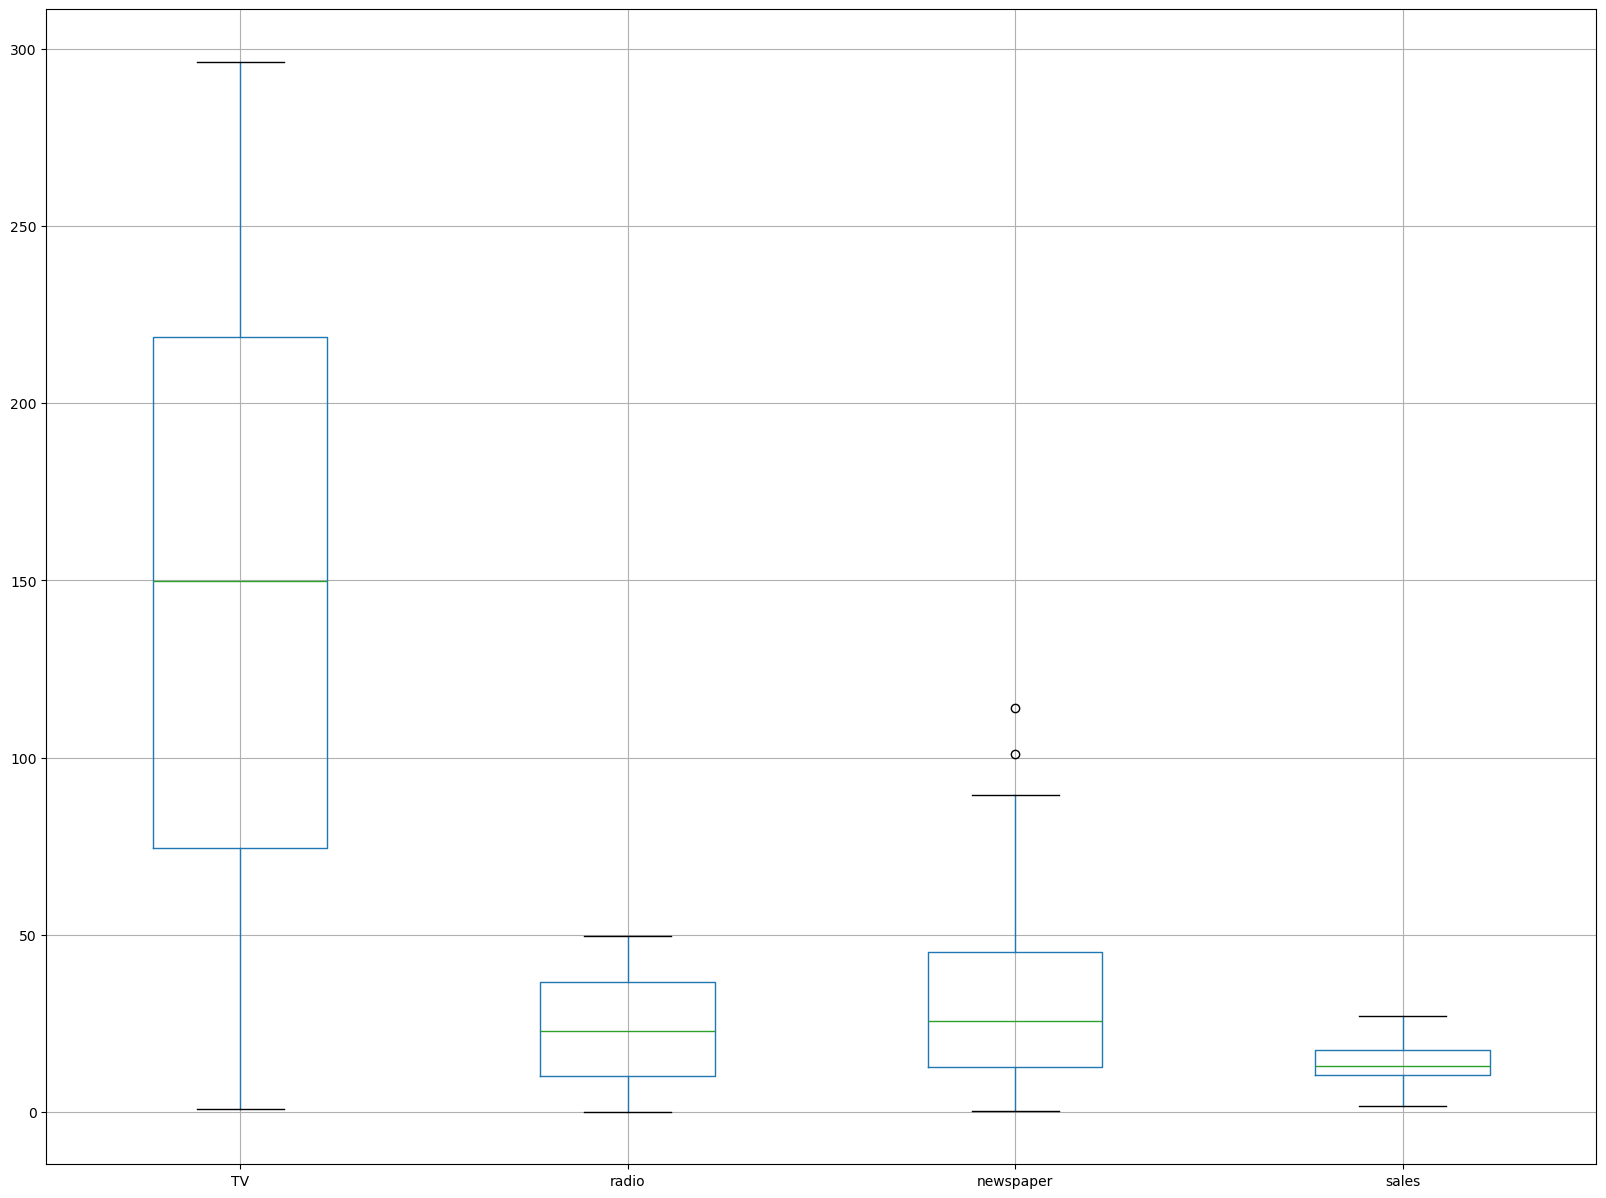

In [6]:
plt.figure(figsize=(20, 15))
df.boxplot()
plt.show()

In [7]:
#fitted_data, fitted_lambda = stats.boxcox(df.sales)

In [8]:
X=df.drop(columns=["sales"])
Y=df["sales"]

In [9]:
#X_train, X_test, Y_train, Y_test = train_test_split(X, Y,random_state = 2,test_size=0.3)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y,random_state = 0,test_size=0.25)

In [10]:
mod = LinearRegression()

mod.fit(X_train,Y_train)
y_pred = mod.predict(X_test)
y_pred_train = mod.predict(X_train)
print(mod.score(X_train,Y_train))
print(mod.score(X_test,Y_test))
print(r2_score(Y_test,y_pred))
errors_train = abs(Y_train) - abs(y_pred_train)
errors_test = abs(Y_test) - abs(y_pred)


0.9072183330817297
0.8576396745320893
0.8576396745320893


In [11]:
mod.coef_

array([0.04416235, 0.19900368, 0.00116268])

 Este conjunto de datos busca estimar la venta de una serie de items con base en la inversión publicitaria en canales como la tv, radio y periodico. Vemos que ajustando el modelo tenemos un r2 en el conjunto de test de .85 (explicamos un 85% de variabilidad) Además no tenemos señales de overfitting/underfitting.
 
 Vamos a validar los supuestos

### LINEALIDAD

Este supuesto podemos empezar a validarlo sin la necesidad de ajustar el modelo. En este caso debemos graficar cada una de las variables predictoras con nuestra variable objetivo y ver una relación lineal entre ellas

C:\Users\schav\anaconda3\Lib\site-packages\seaborn\axisgrid.py:2095: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


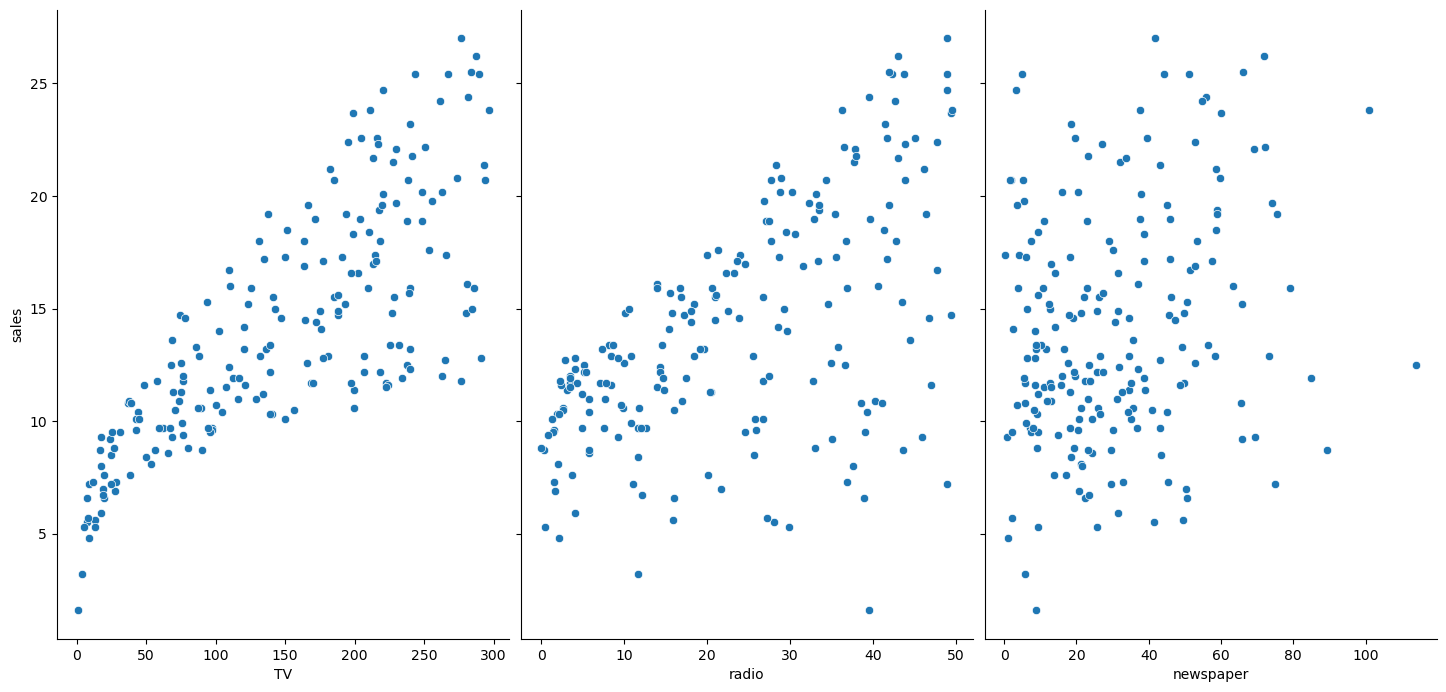

In [12]:
sns.pairplot(df, x_vars=['TV','radio','newspaper'], y_vars='sales', size=7, aspect=0.7)

Podemos ver como dos de nuestras variables predictoras (tv y radio) tienen esa relación lineal , en el caso de newspaper no podemos decir lo mismo, ya que no se muestra una relación lineal o una tendencia entre las ventas y este medio de pauta publicitaria.
podríamos ver la matriz de correlación para confirmar esto

In [13]:
df.corr()

,TV,radio,newspaper,sales
TV,1.000000,0.054809,0.056648,0.782224
radio,0.054809,1.000000,0.354104,0.576223
newspaper,0.056648,0.354104,1.000000,0.228299
sales,0.782224,0.576223,0.228299,1.000000


con la correlacion de .22 , la cual es muy baja, confirmamos lo que vimos inicialmente en los graficos

otra forma de validar es encontrar un patron lineal entre los valores reales y las predicciones

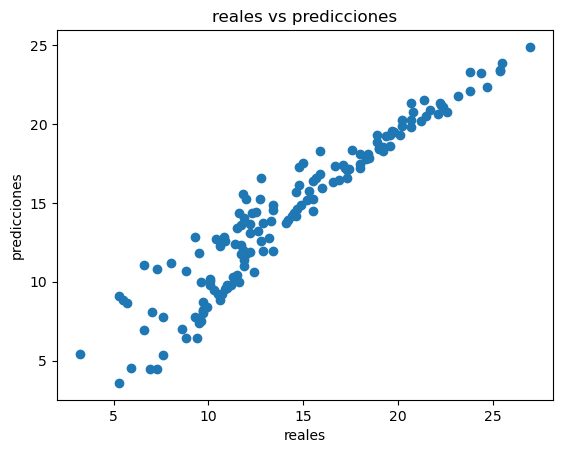

In [14]:
plt.figure()
plt.scatter(Y_train.tolist(),y_pred_train.tolist())
plt.xlabel("reales")
plt.ylabel("predicciones")
plt.title("reales vs predicciones")
plt.show()

In [15]:
### una forma adicional es graficar cada variable predictora con los residuos y encontrar un patrón aleatorio

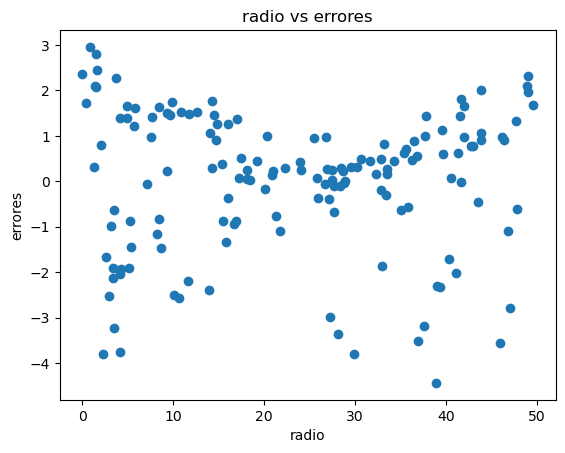

In [16]:
plt.figure()
plt.scatter(X_train["radio"].tolist(),errors_train.tolist())
plt.xlabel("radio")
plt.ylabel("errores")
plt.title("radio vs errores")
plt.show()

EN ESTE SUPUESTO ESTAMOS OK, AVANZAMOS AL SIGUIENTE

### MEDIA DE LOS RESIDUOS

Para validar esta parte debemos ver si la media de los errores es igual a cero

In [17]:
errors_train.mean() 

-1.6105635343895603e-15

tenemos un valor cercano a cero, por lo tanto estamos ok

### HOMOCEDASTICIDAD 

La homocedasticidad significa que los residuos tienen una varianza igual o casi igual a lo largo de la línea de regresión (NO ESTÁ EN TERMINOS DE UNA FUNCIÓN). Al graficar los errores con las predicciones podemos comprobar que no debe haber ningún patrón en los términos de error.

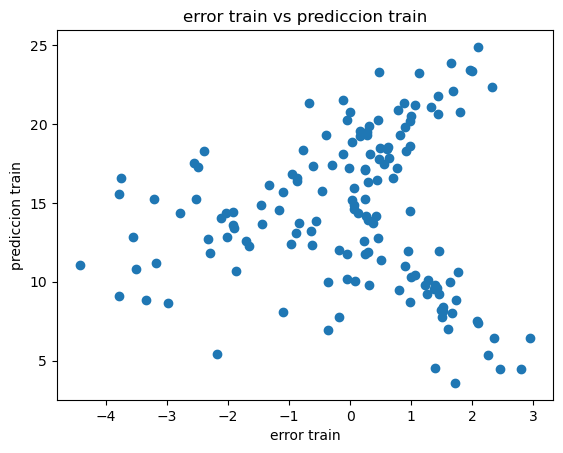

In [18]:
plt.figure()
plt.scatter(errors_train,y_pred_train)
plt.xlabel("error train")
plt.ylabel("prediccion train")
plt.title("error train vs prediccion train")
plt.show()

podemos hacer tambien test Goldfeld Quandt  que plantea las siguientes hipotesis:

$ H_0 $ : en los errores hay homocedasticidad

$ H_1 $ : en los errores hay heterocedasticidad

In [19]:
gold_feldtest = sms.het_goldfeldquandt(errors_train, X_train)
print(gold_feldtest) # el segundo valor es el p value

(1.1098849261262684, 0.32971884319413575, 'increasing')


con un 95% de confianza y teniendo un p value mayor a .05 no rechazamos la hipotesis nula que dice que hay homocedasticidad. Estamos ok

podemos utilizar el test de het_white para determinar lo mismo si utilizamos la funcion ols() en lugar de LinearRegression()

### ERRORES NO AUTOCORRELACIONADOS (independencia de errores)

Cuando los errores estan autocorrelacionados significa que los valores actuales dependen de valores historicos,
esto es mas comun en el contexto de series de tiempo


$\textbf{La autocorrelación}$ de una serie de datos discreta de un proceso $X_t$ no es más
que el coéficiente de correlación de dicho proceso con una versión desplazada de la propia
serie Sea $e_1,...e_n$ una serie de datos el coeficiente de autocorrelación es:

$$
    \rho_k=\dfrac{\sum_{i=1}^{n-k}(e_i-\bar{e})(e_{i-k}-\bar{e})}{\sum_{i=1}^{n-k}(e_i-\bar{e})^2}
$$
Si $\rho_k$ se aleja del valor 0 hay evidencia de que cada k observaciones hay un patrón de los
residuales pues dichas observaciones están muy correlacionadas lo que implicará dependencia
de los residuales. Entoncesla idea es contrastar $\rho_k=0$ vs $\rho_k\neq 0$ . R tiene programada la prueba en la función $acf$.
En la siguiente gráfica se espera que todas las correlaciones estén dentro de la banda de confianza, salvo por la primera que toma el valor de 1. Si para alguna observación se sale de la banda de confianza se dice que se encontro una correlación estadísticamente significativa y hay un patrón en los residuales. 

<Figure size 2000x1000 with 0 Axes>

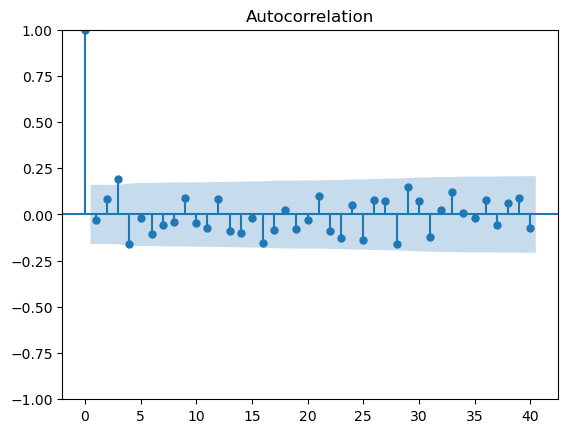

In [20]:
errors_train.index = pd.Index(sm.tsa.datetools.dates_from_range('1','150'))
plt.figure(figsize=(20,10))
f=sm.graphics.tsa.plot_acf(errors_train.values.squeeze(), lags=40)

estamos bien, pues no tenemos valores fuera de las bandas de confianza

En este caso tambien podemos hacer el test de durbin watson:

$ H_0 $ no hay correlacion en los residuos

$ H_1 $  hay correlacion en los residuos

In [21]:
durbin_watson(errors_train)

2.055498930463608

Un valor cercano a 2 sugiere que no hay autocorrelación en los residuos.
Un valor menor que 2 indica una autocorrelación positiva en los residuos.
Un valor mayor que 2 indica una autocorrelación negativa en los residuos.

### Atajo para probar esperanza cero, homocedasticidad y errores no autocorrelacionados

Si la grafica entre los valores ajustados y los residuos estandarizados, muestra un patron aleatorio,
es simetrica alrededor del cero y los puntos estan comprendidos entre los valores -2 y 2, entonces
se tendrá evidencia que los errores tienen media cero, varianza constante y no estan correlacionados.


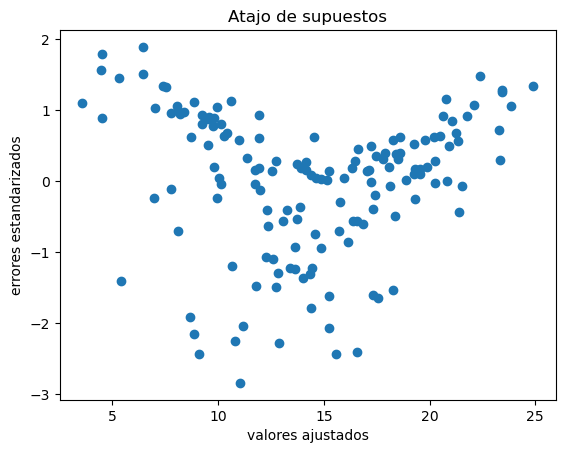

In [22]:
plt.figure()
plt.scatter(y_pred_train,(errors_train - errors_train.mean()) / np.std(errors_train))
plt.xlabel("valores ajustados")
plt.ylabel("errores estandarizados")
plt.title("Atajo de supuestos")
plt.show()

Lo anterior es un metodo grafico y siempre es preferible probar individualmente cada uno de los supuestos

### Normalidad de los errores

Esta parte la podemos verificar haciendo el histograma de los errores y viendo si la distribución tiene la forma de una distribución normal

C:\Users\schav\AppData\Local\Temp\ipykernel_23268\2158146467.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p = sns.distplot(errors_train,kde=True)
C:\Users\schav\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


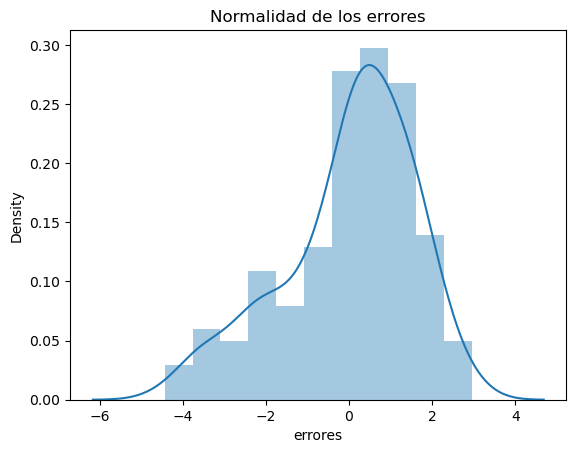

In [23]:
p = sns.distplot(errors_train,kde=True)
plt.xlabel("errores")
p = plt.title('Normalidad de los errores') 

aproximadamente se ve normal. La otra forma es con el grafico conocido como QQ plot o QQ Norm, que grafica los cuantiles teoricos
de una normal (eje x) vs. los cuantiles asociados a los residuos. Entonces, si los residuos realmente
provienen de una normal, la grafica debe mostrar una liınea a 45 grados que pasa por el origen de coordenadas. Fuertes desviaciones de esta linea daránn evidencia de que los errores no se distribuyen
normal.

Text(0.5, 1.0, 'QQ Plot')

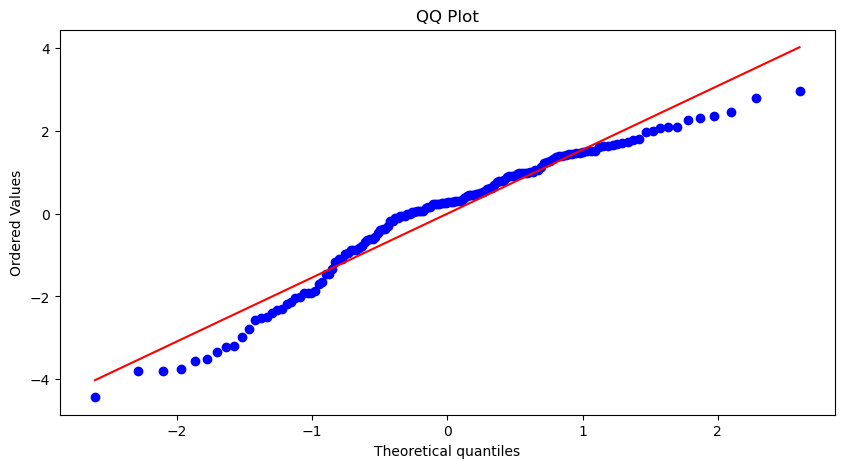

In [24]:
pylab.figure(figsize=(10,5))
stats.probplot(errors_train, dist="norm", plot=pylab) 
pylab.title('QQ Plot') 
#pylab.plot() 

la manera mas formal es haciendo una prueba de bondad de ajuste como puede ser kolmogorov-smirnov,anderson-darling,shapiro-wilk

$ H_0 $ : los errores distribuyen normal

$ H_1 $ : los errores no distribuyen normal

In [25]:
p_value = normal_ad(errors_train)[1]
p_value

1.6731015917057128e-06

In [26]:
stats.kstest(errors_train, "norm", alternative='less')

KstestResult(statistic=0.1437414449358042, pvalue=0.0018101482407005783, statistic_location=0.8794012090651329, statistic_sign=-1)

 en este caso los errores no distribuyen normal.

### NO MULTICOLINEALIDAD EN VARIABLES PREDICTORAS

Como se dijo al inicio del script , queremos evitar que las variables predictoras sean combinación lineal de otras, de manera más estadística buscamos variables que no estén altamente correlacionadas unas de otras. Podemos mirar la matriz de correlación y ver que no tengamos valores muy altos entre las variables predictoras

In [27]:
df.corr()

,TV,radio,newspaper,sales
TV,1.000000,0.054809,0.056648,0.782224
radio,0.054809,1.000000,0.354104,0.576223
newspaper,0.056648,0.354104,1.000000,0.228299
sales,0.782224,0.576223,0.228299,1.000000


el valor mas alto que encontramos es el de radio y newspaper que tiene un valor de .35, el cual no es un valor que genere una alerta.

tambien podemos utilizar mas formalmente los valroes de inflación de varianza (vif) definido como
$$
VIF_q=\dfrac{1}{1-R_q^2}\hspace{1cm}q\in{0,..,k}
$$
Entonces si $R_q^2\approx 1$ eso se traduce en un $VIF_q$ grande, en la práctica se suele tomar como punto de corte 5 o 10, es decir obtener un $VIFq > 10$ nos habla de que la variable Xq puede ser expresada aproximadamente como combinación lineal de las restantes y por tanto podemos tener problemas númericos en las estimaciones.

In [28]:
VIF = pd.DataFrame()
VIF["Covariables"] = X.columns
VIF["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
VIF

,Covariables,VIF
0,TV,2.486772
1,radio,3.285462
2,newspaper,3.055245


en nuestro ejemplo tenemos valores de 3 , por lo que no tenemos problemas con la multicolinealidad

inventamos una columna que sea combinacion lineal de otra para ver la multicolinealidad

In [35]:
X["fakevar"] = (X["TV"]*5)+3

In [36]:
VIF = pd.DataFrame()
VIF["Covariables"] = X.columns
VIF["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
VIF

,Covariables,VIF
0,TV,552681.627135
1,radio,1.144952
2,newspaper,1.145187
3,fakevar,554235.870009


A continuación dejamos un resumen del significado de cada supuesto, en que afecta su invalidación, por qué sucede la invalidación y como podemos arreglarla

### Linealidad:

Supone que la relación entre las variables es lineal. Es decir, los cambios en la variable dependiente son proporcionales a los cambios en las variables independientes.

- ¿Por qué sucede? Asumimos que la relación es lineal para simplificar el modelo y facilitar su interpretación.

- Invalidación: Se invalida si la relación es no lineal.

- Detección: Puede detectarse de forma visual

- Solución: Podría ser necesario utilizar transformaciones logarítmicas u otras transformaciones no lineales en las variables.

- Consecuencias: Predicciones poco precisas (underfitting)

### Independencia de errores:

Los errores del modelo (diferencia entre los valores observados y predichos) deben ser independientes entre sí. La autocorrelación de errores puede invalidar este supuesto.

- ¿Por qué sucede? Si hay patrones sistemáticos en los errores, podrían afectar la validez de las inferencias estadísticas.

- Invalidación: Ocurre si los errores están correlacionados.

- Detección: Se puede detectar mediante pruebas de autocorrelación en los residuos. o graficos de autocorrelacion y autocorrelacion parcial

- Solución: Incluir variables relevantes que se hayan pasado por alto o utilizar técnicas más avanzadas si es necesario como interacciones o transformación en las variables

- Consecuencias: Predicciones incorrectas

### Homocedasticidad: 

La varianza de los errores debe ser constante a lo largo de todos los niveles de las variables independientes.

- ¿Por qué sucede? Si la varianza de los errores cambia, puede afectar la eficiencia de las estimaciones y las pruebas de hipótesis.

- Invalidación: Se invalida si hay patrones discernibles en la dispersión de los residuos.

- Detección: Puede identificarse graficamente o utilizando la prueba de Goldfeld Quandt o la prueba de white

- Solución: Eliminar datos atipicos.Transformaciones de variables o la inclusión de variables adicionales pueden ayudar a estabilizar la varianza. Aplicar un logaritmo a la variable que queremos predecir tambien es de ayuda

- Consecuencias: Afecta los resultados en las pruebas de hipotesis y los valores de intervalos de confianza 



### Normalidad de errores: 

Supone que los errores de predicción siguen una distribución normal.

- ¿Por qué sucede?  Simplifica las inferencias estadísticas y prueba de hipótesis.

- Invalidación: No es crítico para tamaños de muestra grandes debido al teorema del límite central, pero es importante para tamaños de muestra pequeños.

- Detección: Pruebas de normalidad sobre los residuos pueden identificar la no normalidad, así como el grafico qqplot

 - Consecuencias: predicciones puntuales como intervalos de confianza afectados

 - Solución: Eliminar datos atipicos.Pueden utilizarse transformaciones de datos o métodos robustos si la normalidad está seriamente comprometida. Tambien se puede aplicar la transformacion de box cox la cual se denota como sigue:
 
 <img src="box cox.png">
 

 
 

 


P-valor de la prueba de Shapiro-Wilk antes de Box-Cox: 0.0000
P-valor de la prueba de Shapiro-Wilk después de Box-Cox: 0.7711
Lambda óptimo de Box-Cox: 0.4196


C:\Users\schav\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\schav\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


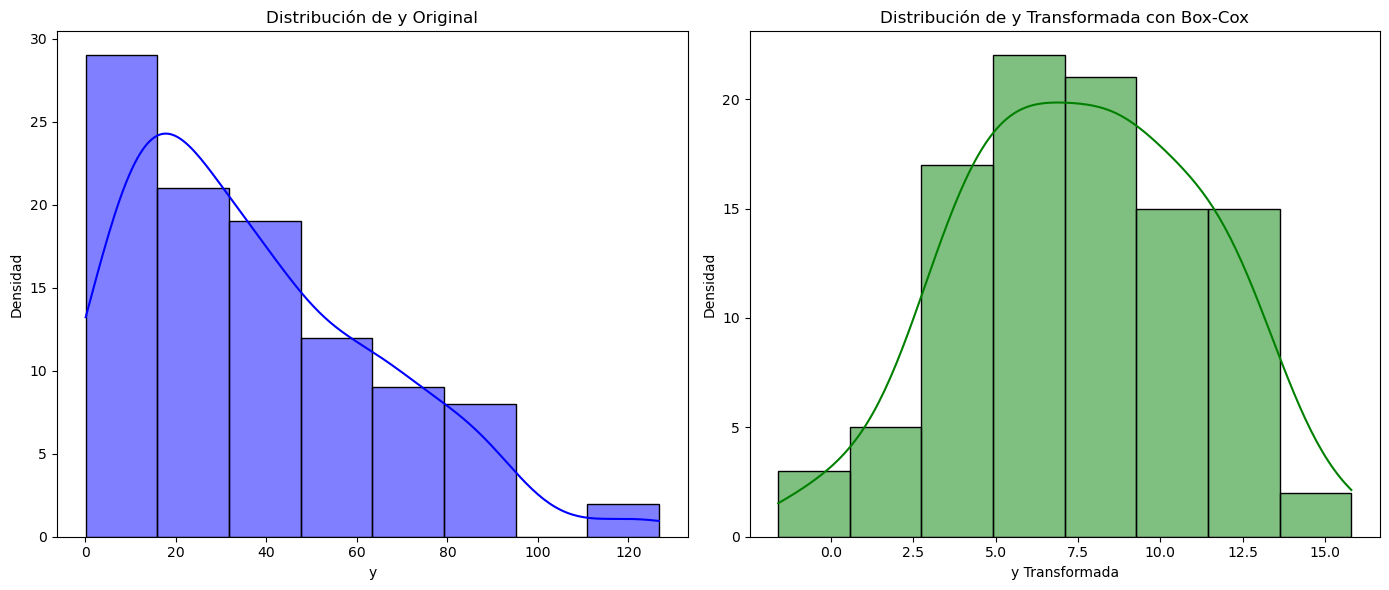

In [41]:
import numpy as np
import pandas as pd
from scipy.stats import boxcox, shapiro, norm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import seaborn as sns

# Generación de un dataset de ejemplo
X, y = make_regression(n_samples=100, n_features=1, noise=20, random_state=42)
y = np.abs(y)  

# Ajuste del modelo de regresión con scikit-learn
modelo = LinearRegression()
modelo.fit(X, y)

# Predicción y cálculo de residuos
y_pred = modelo.predict(X)
residuos = y - y_pred

# Diagnóstico inicial de normalidad de los errores
_, p_value_original = shapiro(residuos)
print(f'P-valor de la prueba de Shapiro-Wilk antes de Box-Cox: {p_value_original:.4f}')

# Transformación Box-Cox
y_trans, lambda_ = boxcox(y)

# Ajuste del modelo con la respuesta transformada
modelo_bc = LinearRegression()
modelo_bc.fit(X, y_trans)

# Predicción y cálculo de residuos con la variable transformada
y_trans_pred = modelo_bc.predict(X)
residuos_bc = y_trans - y_trans_pred

# Diagnóstico de normalidad de los errores después de la transformación
_, p_value_bc = shapiro(residuos_bc)
print(f'P-valor de la prueba de Shapiro-Wilk después de Box-Cox: {p_value_bc:.4f}')
print(f'Lambda óptimo de Box-Cox: {lambda_:.4f}')


# Gráfica de la curva de distribución de y original y y Box-Cox
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(y, kde=True, color='blue')
plt.title('Distribución de y Original')
plt.xlabel('y')
plt.ylabel('Densidad')

plt.subplot(1, 2, 2)
sns.histplot(y_trans, kde=True, color='green')
plt.title('Distribución de y Transformada con Box-Cox')
plt.xlabel('y Transformada')
plt.ylabel('Densidad')

plt.tight_layout()
plt.show()

### Multicolinealidad: 

Este supuesto se refiere a la correlación alta entre dos o más variables independientes en el modelo.

- ¿Por qué sucede? Puede ocurrir cuando dos o más variables independientes están fuertemente relacionadas, lo que dificulta discernir el efecto individual de cada variable sobre la variable dependiente.

- Invalidación: Se invalida si hay una alta correlación entre las variables independientes.

- Detección: Se puede detectar mediante estadísticas como el índice de variación de inflación (VIF) para cada variable independiente.

- Solución: Reducir la dimensionalidad del modelo eliminando variables redundantes o combinándolas. También se puede utilizar técnicas como la regularización (por ejemplo, la regresión de Ridge) para manejar la multicolinealidad. Si dos variables están altamente correlacionadas se elimina una y se conserva la que tenga mayor correlación con la variable respuesta 